In [ ]:

!pip install -q findspark

from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("BDA_Assignment").getOrCreate()

print("Spark Installed Successfully!")

Spark Installed Successfully!


## **1. CLASSIFICATION (Titanic + Metrics + Visualization)**

+------+----+-----+-----+-------+--------+
|Pclass| Age|SibSp|Parch|   Fare|Survived|
+------+----+-----+-----+-------+--------+
|     3|22.0|    1|    0|   7.25|       0|
|     1|38.0|    1|    0|71.2833|       1|
|     3|26.0|    0|    0|  7.925|       1|
|     1|35.0|    1|    0|   53.1|       1|
|     3|35.0|    0|    0|   8.05|       0|
+------+----+-----+-----+-------+--------+
only showing top 5 rows
+--------------------+-----+----------+
|            features|label|prediction|
+--------------------+-----+----------+
|(5,[0,1],[1.0,40.0])|    0|       1.0|
|(5,[0,1],[3.0,49.0])|    0|       0.0|
|[1.0,2.0,1.0,2.0,...|    0|       1.0|
|[1.0,16.0,0.0,0.0...|    1|       1.0|
|[1.0,18.0,0.0,2.0...|    1|       1.0|
|[1.0,19.0,0.0,0.0...|    1|       1.0|
|[1.0,21.0,0.0,1.0...|    0|       1.0|
|[1.0,22.0,1.0,0.0...|    1|       1.0|
|[1.0,24.0,3.0,2.0...|    1|       1.0|
|[1.0,25.0,1.0,0.0...|    1|       1.0|
|[1.0,25.0,1.0,0.0...|    1|       1.0|
|[1.0,26.0,0.0,0.0...|    1| 

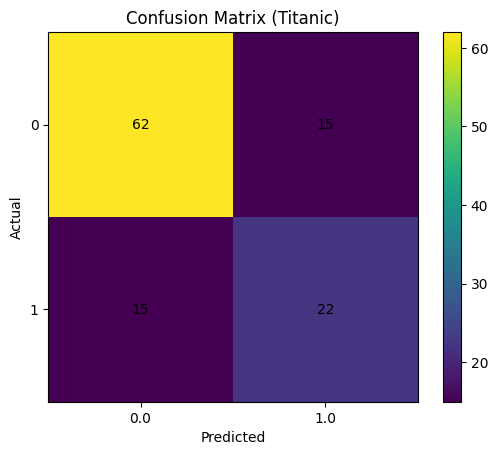

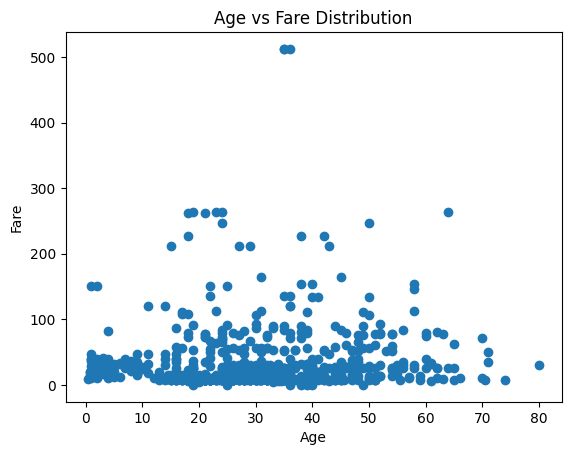

In [ ]:

import requests

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
local_file_path = "titanic.csv"


response = requests.get(url)
response.raise_for_status()

with open(local_file_path, "wb") as f:
    f.write(response.content)

df = spark.read.csv(local_file_path, header=True, inferSchema=True)


df = df.select("Pclass","Age","SibSp","Parch","Fare","Survived").dropna()

df.show(5)


from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Pclass","Age","SibSp","Parch","Fare"],
    outputCol="features"
)

data = assembler.transform(df).select("features","Survived")
data = data.withColumnRenamed("Survived","label")


from pyspark.ml.classification import LogisticRegression

train, test = data.randomSplit([0.8,0.2], seed=42)

model = LogisticRegression().fit(train)

pred = model.transform(test)

pred.select("features","label","prediction").show()


from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator = MulticlassClassificationEvaluator()

print("Accuracy:", evaluator.setMetricName("accuracy").evaluate(pred))
print("Precision:", evaluator.setMetricName("weightedPrecision").evaluate(pred))
print("Recall:", evaluator.setMetricName("weightedRecall").evaluate(pred))
print("F1 Score:", evaluator.setMetricName("f1").evaluate(pred))


import matplotlib.pyplot as plt
import pandas as pd


pdf = pred.select("label", "prediction").toPandas()


cm = pd.crosstab(pdf['label'], pdf['prediction'])

print("\nConfusion Matrix:\n", cm)

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (Titanic)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks(range(len(cm.columns)), cm.columns)
plt.yticks(range(len(cm.index)), cm.index)

for i in range(len(cm.index)):
    for j in range(len(cm.columns)):
        plt.text(j, i, cm.iloc[i, j], ha='center', va='center')

plt.colorbar()
plt.show()


pdf_full = df.toPandas()

plt.figure()
plt.scatter(pdf_full["Age"], pdf_full["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare Distribution")
plt.show()

## **2. CLUSTERING (K-Means + Metrics + Visualization + Elbow)**

+-------+------+-----+----+-------+------+----------------+----------+
|Channel|Region|Fresh|Milk|Grocery|Frozen|Detergents_Paper|Delicassen|
+-------+------+-----+----+-------+------+----------------+----------+
|      2|     3|12669|9656|   7561|   214|            2674|      1338|
|      2|     3| 7057|9810|   9568|  1762|            3293|      1776|
|      2|     3| 6353|8808|   7684|  2405|            3516|      7844|
|      1|     3|13265|1196|   4221|  6404|             507|      1788|
|      2|     3|22615|5410|   7198|  3915|            1777|      5185|
+-------+------+-----+----+-------+------+----------------+----------+
only showing top 5 rows
+-----+-----+----------+
|Fresh| Milk|prediction|
+-----+-----+----------+
|12669| 9656|         0|
| 7057| 9810|         0|
| 6353| 8808|         0|
|13265| 1196|         0|
|22615| 5410|         1|
| 9413| 8259|         0|
|12126| 3199|         0|
| 7579| 4956|         0|
| 5963| 3648|         0|
| 6006|11093|         0|
| 3366| 5403

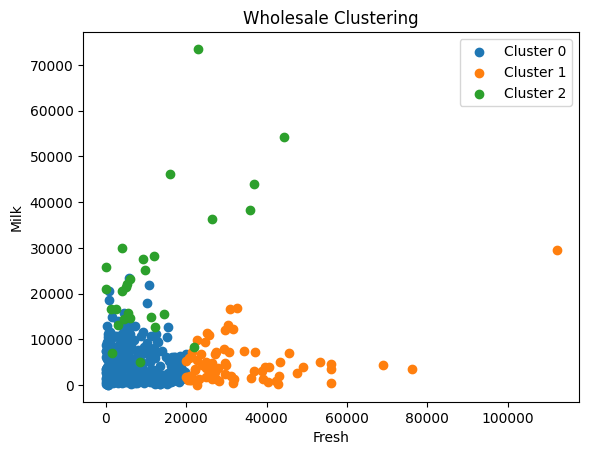

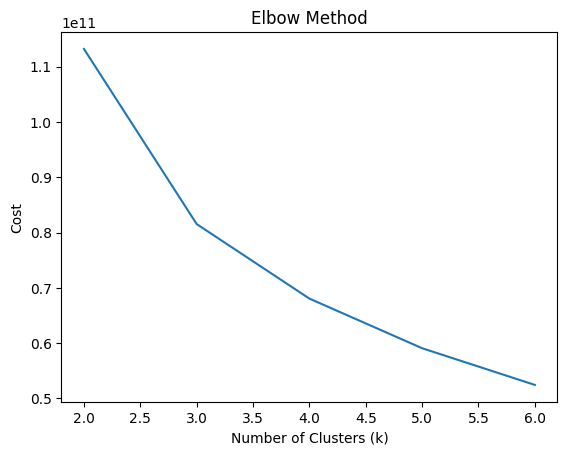

In [ ]:

import requests

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
local_file_path = "wholesale-customers.csv"


response = requests.get(url)
response.raise_for_status()

with open(local_file_path, "wb") as f:
    f.write(response.content)

df = spark.read.csv(local_file_path, header=True, inferSchema=True)

df.show(5)


from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["Fresh","Milk","Grocery","Frozen","Detergents_Paper","Delicassen"],
    outputCol="features"
)
data = assembler.transform(df)


from pyspark.ml.clustering import KMeans

kmeans = KMeans(k=3, seed=1)
model = kmeans.fit(data)

pred = model.transform(data)
pred.select("Fresh","Milk","prediction").show()


from pyspark.ml.evaluation import ClusteringEvaluator

silhouette = ClusteringEvaluator().evaluate(pred)
print("Silhouette Score:", silhouette)


import matplotlib.pyplot as plt
import pandas as pd

pdf = pred.select("Fresh","Milk","prediction").toPandas()

plt.figure()
for c in sorted(pdf['prediction'].unique()):
    subset = pdf[pdf['prediction']==c]
    plt.scatter(subset["Fresh"], subset["Milk"], label=f"Cluster {c}")

plt.xlabel("Fresh")
plt.ylabel("Milk")
plt.title("Wholesale Clustering")
plt.legend()
plt.show()


cost = []
k_values = range(2, 7)

for k in k_values:
    km = KMeans(k=k, seed=1)
    m = km.fit(data)
    cost.append(m.summary.trainingCost)

plt.figure()
plt.plot(k_values, cost)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Cost")
plt.title("Elbow Method")
plt.show()

## **3. RECOMMENDATION SYSTEM (Goodbooks + RMSE + Visualization)**


+-------+-------+------+
|user_id|book_id|rating|
+-------+-------+------+
|      1|    258|     5|
|      2|   4081|     4|
|      2|    260|     5|
|      2|   9296|     5|
|      2|   2318|     3|
+-------+-------+------+
only showing top 5 rows
root
 |-- user_id: integer (nullable = true)
 |-- book_id: integer (nullable = true)
 |-- rating: integer (nullable = true)

+-------+-------+------+----------+
|user_id|book_id|rating|prediction|
+-------+-------+------+----------+
|    463|     10|     5| 3.4903512|
|    463|     27|     3| 3.6408622|
|    463|     28|     2| 3.2157457|
|    463|     32|     2| 3.3809488|
|    463|     39|     1| 3.7023418|
+-------+-------+------+----------+
only showing top 5 rows
RMSE: 0.821214380071894
+-------+----------------------------------------------------------------------------------------------+
|user_id|recommendations                                                                               |
+-------+-----------------------------------

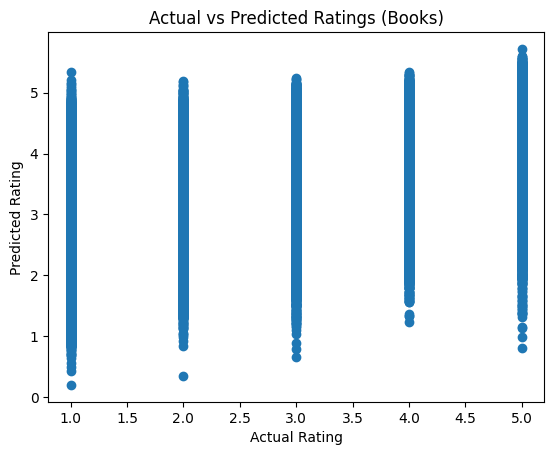

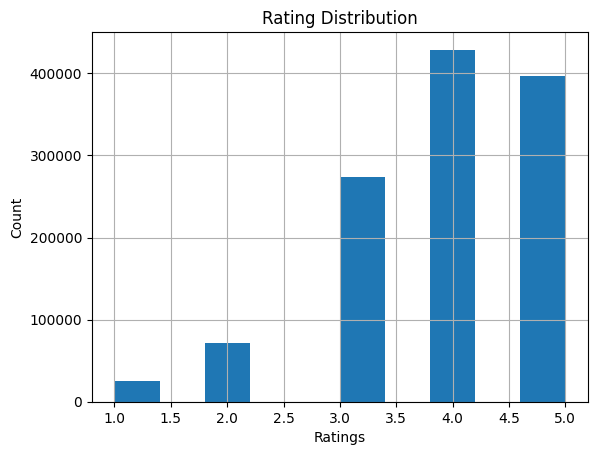

In [ ]:

import requests

url = "https://raw.githubusercontent.com/zygmuntz/goodbooks-10k/master/ratings.csv"


response = requests.get(url)
with open("ratings.csv", "w") as f:
    f.write(response.text)

ratings = spark.read.csv("ratings.csv", header=True, inferSchema=True)

ratings.show(5)
ratings.printSchema()


train, test = ratings.randomSplit([0.8, 0.2], seed=42)


from pyspark.ml.recommendation import ALS

als = ALS(
    userCol="user_id",
    itemCol="book_id",
    ratingCol="rating",
    coldStartStrategy="drop"
)

model = als.fit(train)


pred = model.transform(test)
pred.show(5)


from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    metricName="rmse",
    labelCol="rating",
    predictionCol="prediction"
)

rmse = evaluator.evaluate(pred)
print("RMSE:", rmse)


recs = model.recommendForAllUsers(5)
recs.show(truncate=False)


import matplotlib.pyplot as plt
import pandas as pd

pdf = pred.select("rating", "prediction").toPandas()

plt.figure()
plt.scatter(pdf["rating"], pdf["prediction"])
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Ratings (Books)")
plt.show()


plt.figure()
pdf["rating"].hist()
plt.title("Rating Distribution")
plt.xlabel("Ratings")
plt.ylabel("Count")
plt.show()